# 03 – Autoencoder + XGBoost (ideia do professor)

Pipeline sugerido pelo professor:
```
Imagens → CNN Encoder (treino não-supervisionado em TODO o dataset)
        → Latent Space (~2048 dim, reduzido para ~512 com PCA)
        → XGBoost / SVM (treino supervisionado só nas 5519 imagens labeled)
```

**Vantagens:**
- Aproveita as ~19k imagens não-labeladas para aprender representações
- XGBoost lida melhor com classes desequilibradas via `scale_pos_weight`
- Muito mais rápido de treinar que uma CNN completa

In [3]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 10.4 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 10.0 MB/s  0:00:29m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


In [1]:
import os, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score)
from sklearn.preprocessing import label_binarize
import xgboost as xgb
from sklearn.svm import SVC
import joblib

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
# ─── CONFIG ───────────────────────────────────────────────────────────────────
DATASET_PROCESSED = os.environ.get('OUT_DIR',        './dataset_processed')  # labeled
DATASET_RAW       = os.environ.get('RAW_BASE_DIR',   './dataset_processed')
TARGET_SIZE       = (128, 128)  # mais pequeno para o autoencoder — suficiente
BATCH_SIZE_AE     = 64
EPOCHS_AE         = 30
LR_AE             = 1e-3
LATENT_DIM        = 512
PCA_COMPONENTS    = 256    # reduzir antes do XGBoost
AE_PATH           = '../models/autoencoder_best2.pth'
os.makedirs('../models', exist_ok=True)
# ──────────────────────────────────────────────────────────────────────────────

## 1. Dataset para o Autoencoder (imagens não-labeladas + labeladas)

In [3]:
class UnlabeledImageDataset(Dataset):
    """Carrega todas as imagens sem labels — para treino não-supervisionado."""
    def __init__(self, root_dirs, size=(128, 128)):
        self.files = []
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        for root in root_dirs:
            for dirpath, _, fnames in os.walk(root):
                for f in fnames:
                    if f.lower().endswith(valid_exts):
                        self.files.append(os.path.join(dirpath, f))
        print(f'Total imagens para autoencoder: {len(self.files)}')

        self.transform = transforms.Compose([
            transforms.Resize(size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        img = cv2.imread(self.files[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((128, 128), dtype=np.uint8)
        from PIL import Image
        img_pil = Image.fromarray(img)
        return self.transform(img_pil)


# Usar tanto as imagens processadas (labeled) como as raw (unlabeled)
ae_dataset = UnlabeledImageDataset(
    root_dirs=[DATASET_PROCESSED, DATASET_RAW],
    size=TARGET_SIZE
)
ae_loader = DataLoader(ae_dataset, batch_size=BATCH_SIZE_AE, shuffle=True,
                        num_workers=4, drop_last=True)

Total imagens para autoencoder: 3138


## 2. Arquitetura do Autoencoder Convolucional

In [4]:
class ConvAutoencoder(nn.Module):
    """
    Encoder: 128×128 → 512-dim vector
    Decoder: 512-dim → 128×128 (reconstrução)
    """
    def __init__(self, latent_dim=512):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32,  3, stride=2, padding=1),  # 64×64
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 32×32
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 16×16
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),# 8×8
            nn.BatchNorm2d(256), nn.ReLU(),
        )
        self.flatten   = nn.Flatten()
        self.fc_enc    = nn.Linear(256 * 8 * 8, latent_dim)

        # Decoder
        self.fc_dec    = nn.Linear(latent_dim, 256 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), # 16×16
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  3, stride=2, padding=1, output_padding=1), # 32×32
            nn.BatchNorm2d(64),  nn.ReLU(),
            nn.ConvTranspose2d(64, 32,   3, stride=2, padding=1, output_padding=1), # 64×64
            nn.BatchNorm2d(32),  nn.ReLU(),
            nn.ConvTranspose2d(32, 1,    3, stride=2, padding=1, output_padding=1), # 128×128
            nn.Tanh()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        return self.fc_enc(x)

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(-1, 256, 8, 8)
        return self.decoder(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


ae_model = ConvAutoencoder(latent_dim=LATENT_DIM).to(DEVICE)
total_params = sum(p.numel() for p in ae_model.parameters())
print(f'Autoencoder — parâmetros: {total_params:,}')

Autoencoder — parâmetros: 17,570,945


## 3. Treino do Autoencoder

Ep   1/30 | Recon Loss: 0.162980
  ✅ Autoencoder guardado (loss=0.162980)


Ep   2/30 | Recon Loss: 0.074085
  ✅ Autoencoder guardado (loss=0.074085)


Ep   3/30 | Recon Loss: 0.060224
  ✅ Autoencoder guardado (loss=0.060224)


Ep   4/30 | Recon Loss: 0.050287
  ✅ Autoencoder guardado (loss=0.050287)


Ep   5/30 | Recon Loss: 0.040934
  ✅ Autoencoder guardado (loss=0.040934)


...

Ep  26/30 | Recon Loss: 0.006905
  ✅ Autoencoder guardado (loss=0.006905)


Ep  27/30 | Recon Loss: 0.006790
  ✅ Autoencoder guardado (loss=0.006790)


Ep  28/30 | Recon Loss: 0.006610
  ✅ Autoencoder guardado (loss=0.006610)


Ep  29/30 | Recon Loss: 0.006609
  ✅ Autoencoder guardado (loss=0.006609)


Ep  30/30 | Recon Loss: 0.006556
  ✅ Autoencoder guardado (loss=0.006556)


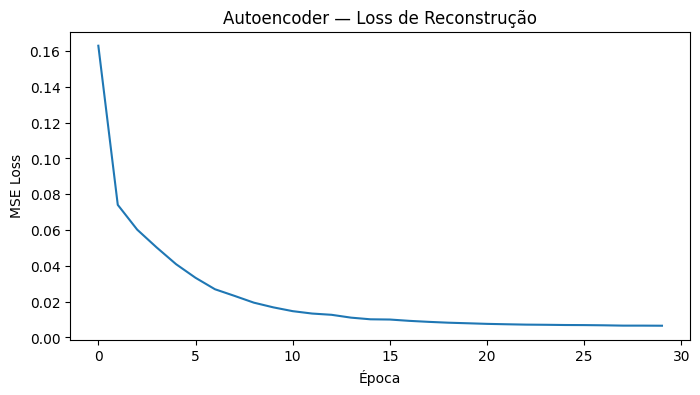

In [ ]:
ae_optimizer = torch.optim.Adam(ae_model.parameters(), lr=LR_AE)
ae_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ae_optimizer, T_max=EPOCHS_AE)

train_losses = []
best_ae_loss = float('inf')

for epoch in range(1, EPOCHS_AE + 1):
    ae_model.train()
    epoch_loss = 0.0

    for imgs in tqdm(ae_loader, desc=f'Ep {epoch}/{EPOCHS_AE}', leave=False):
        imgs = imgs.to(DEVICE)
        recon, _ = ae_model(imgs)
        loss = F.mse_loss(recon, imgs)
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        epoch_loss += loss.item() * imgs.size(0)

    epoch_loss /= len(ae_loader.dataset)
    train_losses.append(epoch_loss)
    ae_scheduler.step()

    print(f'Ep {epoch:3d}/{EPOCHS_AE} | Recon Loss: {epoch_loss:.6f}')

    if epoch_loss < best_ae_loss:
        best_ae_loss = epoch_loss
        torch.save(ae_model.state_dict(), AE_PATH)
        print(f'  ✅ Autoencoder guardado (loss={best_ae_loss:.6f})')

plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title('Autoencoder — Loss de Reconstrução')
plt.xlabel('Época'); plt.ylabel('MSE Loss')
plt.savefig('../results/best/autoencoder_loss_best2.png', dpi=150)
plt.show()

## 4. Visualizar Reconstruções

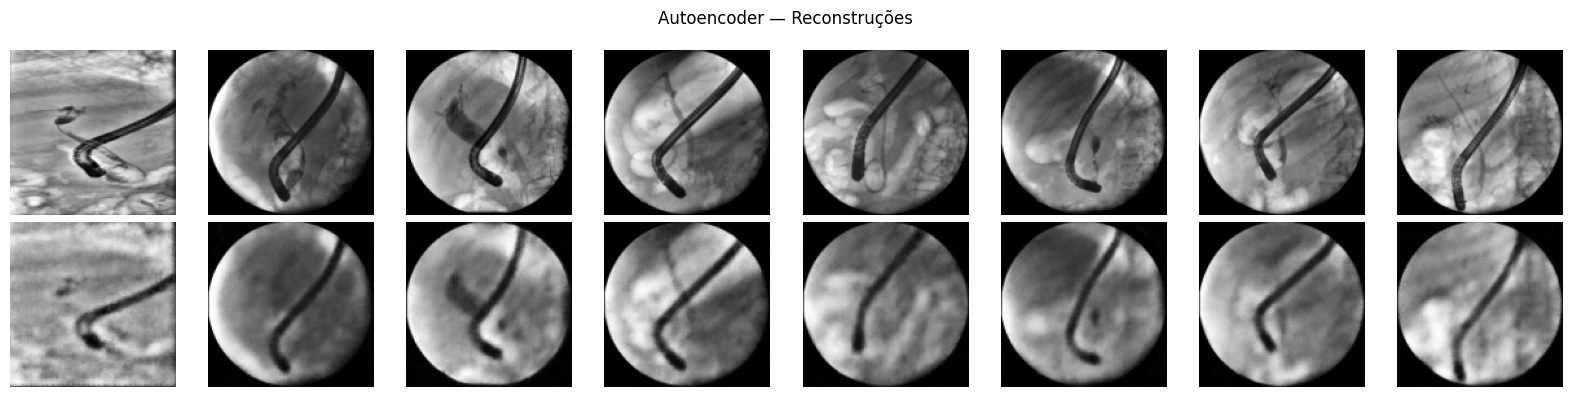

In [ ]:
ae_model.load_state_dict(torch.load(AE_PATH, map_location=DEVICE))
ae_model.eval()

sample_imgs = next(iter(ae_loader))[:8].to(DEVICE)
with torch.no_grad():
    recons, _ = ae_model(sample_imgs)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(sample_imgs[i, 0].cpu(), cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recons[i, 0].cpu(),      cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Reconstrução', fontsize=10)
plt.suptitle('Autoencoder — Reconstruções')
plt.tight_layout()
plt.savefig('../results/best/autoencoder_reconstructions_best2.png', dpi=150)
plt.show()

## 5. Extrair Features do Encoder para as Imagens Labeled

In [7]:
class LabeledDataset(Dataset):
    def __init__(self, image_files, labels, size=(128, 128)):
        self.image_files = image_files
        self.labels = labels
        self.transform = transforms.Compose([
            transforms.Resize(size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def __len__(self): return len(self.image_files)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_files[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((128, 128), dtype=np.uint8)
        from PIL import Image
        return self.transform(Image.fromarray(img)), self.labels[idx]


PHASES = ['train', 'val', 'test']
class_names = sorted([d for d in os.listdir(os.path.join(DATASET_PROCESSED, 'train'))
                       if os.path.isdir(os.path.join(DATASET_PROCESSED, 'train', d))])
NUM_CLASSES = len(class_names)

labeled_data = {phase: {'images': [], 'labels': []} for phase in PHASES}
for phase in PHASES:
    for i, cls in enumerate(class_names):
        cls_dir = os.path.join(DATASET_PROCESSED, phase, cls)
        if not os.path.isdir(cls_dir): continue
        files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                 if f.lower().endswith('.png')]
        labeled_data[phase]['images'].extend(files)
        labeled_data[phase]['labels'].extend([i] * len(files))


@torch.no_grad()
def extract_features(model, image_files, labels, batch_size=64):
    ds = LabeledDataset(image_files, labels, size=TARGET_SIZE)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=4)
    features, all_labels = [], []
    model.eval()
    for imgs, lbls in tqdm(dl, desc='Extraindo features'):
        imgs = imgs.to(DEVICE)
        z = model.encode(imgs)
        features.append(z.cpu().numpy())
        all_labels.extend(lbls.numpy())
    return np.vstack(features), np.array(all_labels)


print('Extraindo features...')
X_train, y_train = extract_features(ae_model, labeled_data['train']['images'], labeled_data['train']['labels'])
X_val,   y_val   = extract_features(ae_model, labeled_data['val']['images'],   labeled_data['val']['labels'])
X_test,  y_test  = extract_features(ae_model, labeled_data['test']['images'],  labeled_data['test']['labels'])

print(f'Train features: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Extraindo features...


Extraindo features: 100%|██████████| 5/5 [00:00<00:00, 15.36it/s]

Train features: (1067, 512) | Val: (234, 512) | Test: (267, 512)


## 6. Redução Dimensional com PCA

PCA 256 componentes explicam 99.9% da variância


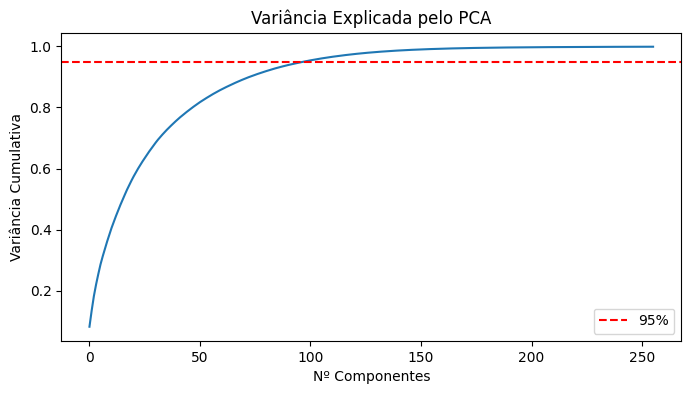

['models/pca_best2.pkl']

In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_s)
X_val_pca   = pca.transform(X_val_s)
X_test_pca  = pca.transform(X_test_s)

explained = np.cumsum(pca.explained_variance_ratio_)
print(f'PCA {PCA_COMPONENTS} componentes explicam {explained[-1]*100:.1f}% da variância')

plt.figure(figsize=(8, 4))
plt.plot(explained)
plt.axhline(0.95, color='red', linestyle='--', label='95%')
plt.title('Variância Explicada pelo PCA')
plt.xlabel('Nº Componentes'); plt.ylabel('Variância Cumulativa')
plt.legend(); plt.savefig('../results/best/pca_variance_best2.png', dpi=150); plt.show()

# Guardar para ensemble
joblib.dump(scaler, '../models/scaler_best2.pkl')
joblib.dump(pca,    '../models/pca_best2.pkl')

## 7. Treino XGBoost

In [ ]:
from collections import Counter

# Calcular scale_pos_weight por classe (para desbalanceamento)
class_counts = Counter(y_train)
max_count = max(class_counts.values())
sample_weight = np.array([max_count / class_counts[y] for y in y_train])

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist',   # GPU: mudar para 'gpu_hist'
    early_stopping_rounds=30
)

print('A treinar XGBoost...')
xgb_model.fit(
    X_train_pca, y_train,
    sample_weight=sample_weight,
    eval_set=[(X_val_pca, y_val)],
    verbose=50
)

joblib.dump(xgb_model, '../models/xgboost_model_best2.pkl')
print('✅ XGBoost guardado')

A treinar XGBoost...
[0]	validation_0-mlogloss:1.38382


/mounts/mecd-ap-g4/.local/lib/python3.10/site-packages/xgboost/callback.py:385: UserWarning: [00:42:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-mlogloss:1.33492
[60]	validation_0-mlogloss:1.33496
✅ XGBoost guardado


## 8. Avaliação XGBoost no Teste


🎯 XGBoost Test F1-Score (macro): 0.2391  (baseline: 0.738)
   Delta vs baseline: -0.4989

               precision    recall  f1-score   support

Biliary_Leaks     0.0000    0.0000    0.0000        17
    Lithiasis     0.4899    0.7886    0.6044       123
       Normal     0.1667    0.0930    0.1194        43
    Stricture     0.3333    0.1786    0.2326        84

     accuracy                         0.4345       267
    macro avg     0.2475    0.2651    0.2391       267
 weighted avg     0.3574    0.4345    0.3708       267

✅ Probabilidades XGBoost guardadas para ensemble


/mounts/mecd-ap-g4/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mounts/mecd-ap-g4/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mounts/mecd-ap-g4/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

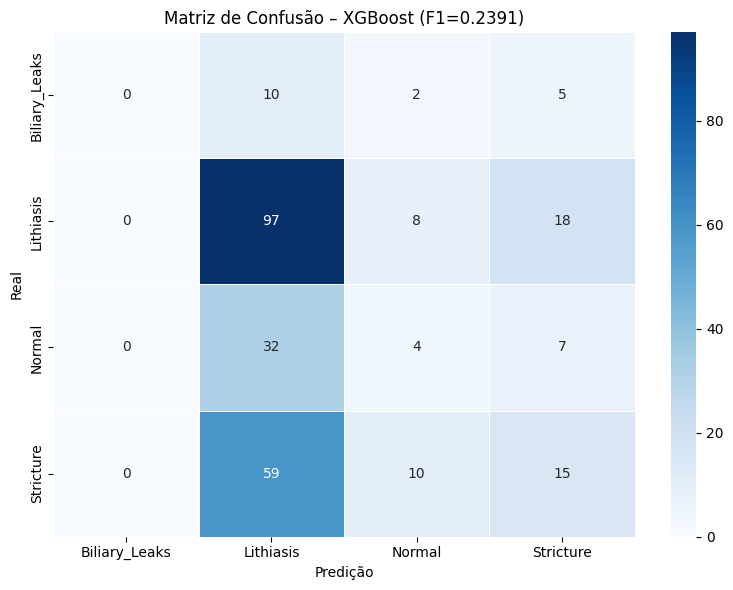

In [ ]:
xgb_preds = xgb_model.predict(X_test_pca)
xgb_probs = xgb_model.predict_proba(X_test_pca)

xgb_f1 = f1_score(y_test, xgb_preds, average='macro')
print(f'\n🎯 XGBoost Test F1-Score (macro): {xgb_f1:.4f}  (baseline: 0.738)')
print(f'   Delta vs baseline: {xgb_f1 - 0.738:+.4f}\n')
print(classification_report(y_test, xgb_preds, target_names=class_names, digits=4))

# Guardar probabilidades para ensemble
np.save('test_probs_xgboost_best2.npy', xgb_probs)
print('✅ Probabilidades XGBoost guardadas para ensemble')

# Matriz de confusão
cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', linewidths=0.5)
plt.title(f'Matriz de Confusão – XGBoost (F1={xgb_f1:.4f})')
plt.xlabel('Predição'); plt.ylabel('Real')
plt.tight_layout()
plt.savefig('../results/best/confusion_matrix_xgboost_best2.png', dpi=150)
plt.show()

## 9. (Opcional) SVM como Alternativa

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=10, gamma='scale',
                class_weight='balanced',
                probability=True, random_state=SEED)

# Treinar em train+val para maximizar dados
X_trainval = np.vstack([X_train_pca, X_val_pca])
y_trainval = np.concatenate([y_train, y_val])

print('A treinar SVM (pode demorar alguns minutos)...')
svm_model.fit(X_trainval, y_trainval)

svm_preds = svm_model.predict(X_test_pca)
svm_probs = svm_model.predict_proba(X_test_pca)
svm_f1    = f1_score(y_test, svm_preds, average='macro')

print(f'\n🎯 SVM Test F1-Score (macro): {svm_f1:.4f}')
print(classification_report(y_test, svm_preds, target_names=class_names, digits=4))

joblib.dump(svm_model, '../models/svm_model_best2.pkl')
np.save('test_probs_svm_best2.npy', svm_probs)

A treinar SVM (pode demorar alguns minutos)...

🎯 SVM Test F1-Score (macro): 0.3009
               precision    recall  f1-score   support

Biliary_Leaks     0.6000    0.1765    0.2727        17
    Lithiasis     0.4681    0.7154    0.5659       123
       Normal     0.1622    0.1395    0.1500        43
    Stricture     0.3514    0.1548    0.2149        84

     accuracy                         0.4120       267
    macro avg     0.3954    0.2966    0.3009       267
 weighted avg     0.3905    0.4120    0.3698       267

